In [2]:
import xml.etree.ElementTree as ET
import numpy as np
from mmct.mmct.force_field import *
from copy import deepcopy
import pandas as pd
from collections import Counter

import sys
sys.path.append('../')
from npc_ana_tool import *

# Dihedral removal

In [2]:
! mv dilated/dilated_CA.xml dilated_CA.xml.old
! mv constricted/constricted_CA.xml constricted_CA.xml.old

In [258]:
! mv dilated/dilated_CA.top dilated_CA.top.old
! mv constricted/constricted_CA.top constricted_CA.top.old

In [259]:
top_d = read_top("dilated_CA.top.old")
top_c = read_top("constricted_CA.top.old")

In [260]:
xml_d = ET.parse("dilated_CA.xml.old")
xml_c = ET.parse("constricted_CA.xml.old")

In [ ]:
def read_angle(top: dict[str, pd.DataFrame]) -> set:
    # WARNING: Only read the first atom. This would only work for CA model
    index = top['angles'].query("`th0(deg)` > 150" or "`th0(deg)` < 30")['ai'].values

    # Make sure that all 8 subunits are included.
    item, count = np.unique(index%N_subunit_CA, return_counts=True)
    non_symmetric_units = item[count != 8]
    symmetric_unit  = np.array([non_symmetric_units + N_subunit_CA*i for i in range(8)]).ravel()

    return set(index).union(set(symmetric_unit))

In [ ]:
# In CA model, delete the dihedrals where the angle is larger than 150 or smaller than 30
# while making sure that the resulting force field is symmetric.
# That is why we can not use the function from mmct.mmct.force_field
def updateDihedral(top: dict[str, pd.DataFrame], xml: ET.ElementTree) -> tuple[dict[str, pd.DataFrame], ET.ElementTree]:
    xml_out = deepcopy(xml)
    index = read_angle(top)
    root = xml_out.getroot()

    for dihedral_type in root.find('dihedrals'):
        modified_dihedrals = []
        for element in dihedral_type:
            if element.tag != 'interaction':
                modified_dihedrals.append(element)
            elif int(element.attrib['i']) in index or int(element.attrib['j']) in index:
                pass
            else:
                modified_dihedrals.append(element)

        dihedral_type[:] = modified_dihedrals

    return top, xml_out

In [ ]:
# Add contacts to make the force field symmetric
def updateContact(top: dict[str, pd.DataFrame], xml: ET.ElementTree) -> tuple[dict[str, pd.DataFrame], ET.ElementTree]:
    xml_out = deepcopy(xml)
    top_out = deepcopy(top)
    root = xml_out.getroot()
    top_exclusion_append = {'ai': [], 'aj': []}

    for contact_type in root.find('contacts'):
        contact_dict = {"i": [], "j": [], "A": [], "B": []}

        for interaction in contact_type.findall("interaction"):
            # Convert dihedral indices from additional to reference

            i = int(interaction.attrib["i"])
            j = int(interaction.attrib["j"])

            contact_dict["i"].append(min(i, j))
            contact_dict["j"].append(max(i, j))

            contact_dict["A"].append(
                float(interaction.attrib["A"])
            )
            contact_dict["B"].append(
                float(interaction.attrib["B"])
            )
        df_contacts = pd.DataFrame(data = contact_dict)

        # extract remainder
        sorted_index_remainder = np.sort(df_contacts[['i', 'j']].values%N_subunit_CA, axis = 1)
        counts_remainder = Counter(map(tuple, sorted_index_remainder))
        unsymmetric = [item for item, count in counts_remainder.items() if count != 8]

        # iter for each contact group
        for i in range(len(unsymmetric)):
            # get the idx of the (incomplete) contact set for each remainder
            extract = (sorted_index_remainder[:, 0] == unsymmetric[i][0]) \
                    & (sorted_index_remainder[:, 1] == unsymmetric[i][1])
            df_tmp = df_contacts[extract]
            idx_existed = df_tmp[['i', 'j']].values

            A = df_tmp['A'].mean()
            B = df_tmp['B'].mean()

            # get the (incomplete) contact set for each remainder
            set_existed = set(map(tuple, idx_existed))

            # get the (complete) contact set for each remainder
            set_all = set()
            for i in range(8):
                set_all.add(tuple(np.sort(idx_existed[0] + i*N_subunit_CA)%(N_subunit_CA*8)))

            # contacts to be appended in this contact group
            set_append = set_all - set_existed

            for pair in set_append:
                contact_type.append(
                    ET.Element(
                        "interaction",
                        attrib={
                            "i": str(pair[0]),
                            "j": str(pair[1]),
                            "A": f"{A:.5e}",
                            "B": f"{B:.5e}",
                        },
                    )
                )

                top_exclusion_append['ai'].append(pair[0])
                top_exclusion_append['aj'].append(pair[1])
    
    top_append = pd.DataFrame(data = top_exclusion_append)
    top_out["exclusions"] = pd.concat([top["exclusions"], top_append])

    return top_out, xml_out

# For single basin

In [264]:
top_new_d, xml_new_d = updateDihedral(top_d, xml_d)
top_new_c, xml_new_c = updateDihedral(top_c, xml_c)

In [265]:
top_new_d, xml_new_d = updateContact(top_new_d, xml_new_d)
top_new_c, xml_new_c = updateContact(top_new_c, xml_new_c)

In [266]:
save_xml(xml_new_d, "dilated/dilated_CA.xml")
save_xml(xml_new_c, "constricted/constricted_CA.xml")

In [267]:
save_top(top_new_d, "dilated/dilated_CA.top")
save_top(top_new_c, "constricted/constricted_CA.top")

In [294]:
# template

save_xml(xml_d, "tmpl_dilated_CA.xml")
save_xml(xml_c, "tmpl_constricted_CA.xml")

save_top(top_d, "tmpl_dilated_CA.top")
save_top(top_c, "tmpl_constricted_CA.top")

In [275]:
! echo >> dilated/dilated_CA.xml
! echo >> constricted/constricted_CA.xml

# For dual basin prerequisite

In [291]:
top4dual_d, xml4dual_d = updateContact(top_d, xml_d)
top4dual_c, xml4dual_c = updateContact(top_c, xml_c)

In [292]:
# template

save_xml(xml4dual_d, "dual_basin/predual_dilated_CA.xml")
save_xml(xml4dual_c, "dual_basin/predual_constricted_CA.xml")

save_top(top4dual_d, "dual_basin/predual_dilated_CA.top")
save_top(top4dual_c, "dual_basin/predual_constricted_CA.top")

In [293]:
! echo >> dual_basin/predual_dilated_CA.xml
! echo >> dual_basin/predual_constricted_CA.xml

# Contact summary

In [ ]:
# ring_info is loaded from ../../npc_ana_tool.py
ring_info['Rings'] = ring_info['CR_all'] + ring_info['IR_all'] + ring_info['NR_all'] + ring_info['Bridge']

ring_indices = get_ring_indices(df_chain_info)
ring_all_indices = get_ring_allsubunits_indices(ring_indices)

In [276]:
tree1 = ET.parse("dilated/dilated_CA.xml")
root1 = tree1.getroot()

In [277]:
tree2 = ET.parse("constricted/constricted_CA.xml")
root2 = tree2.getroot()

In [283]:
n_parts = len(ring_all_indices)

In [284]:
def get_contact_matrix(root, n_parts):
    contact_matrix = np.zeros((n_parts, n_parts), dtype=int)

    for xml in root.find('contacts'):


        for atoms_ij in xml.findall('interaction'):
            for i in range(n_parts):
                if ((int(atoms_ij.attrib['i']) - 1) in ring_all_indices[i]):
                    break
            for j in range(n_parts):
                if ((int(atoms_ij.attrib['j']) - 1) in ring_all_indices[j]):
                    break
            if i == j:
                contact_matrix[i][j] += 1
            else:
                contact_matrix[i][j] += 1
                contact_matrix[j][i] += 1
    return contact_matrix

In [285]:
contact_matrix_dilated = get_contact_matrix(root1, n_parts)

In [286]:
contact_matrix_constricted = get_contact_matrix(root2, n_parts)

In [287]:
list(ring_info.keys())[:5]

['CR_all', 'IR_all', 'NR_all', 'LR_all', 'Bridge']

In [288]:
import matplotlib.pyplot as plt
params={'font.family':'sans-serif',
        'font.sans-serif':'Arial',
        'font.weight':'normal', # or 'blod'
        'figure.figsize': [4, 3],
        'font.size': 12, # or large,small
        'figure.dpi': 300,
        'lines.linewidth': 1.2,
        'mathtext.fontset': 'custom',
        'mathtext.rm': 'Arial',
        'mathtext.it': 'Arial:italic',
        'mathtext.cal': 'Times New Roman:italic',
        'mathtext.tt': 'Times New Roman'
        }
plt.rcParams.update(params)

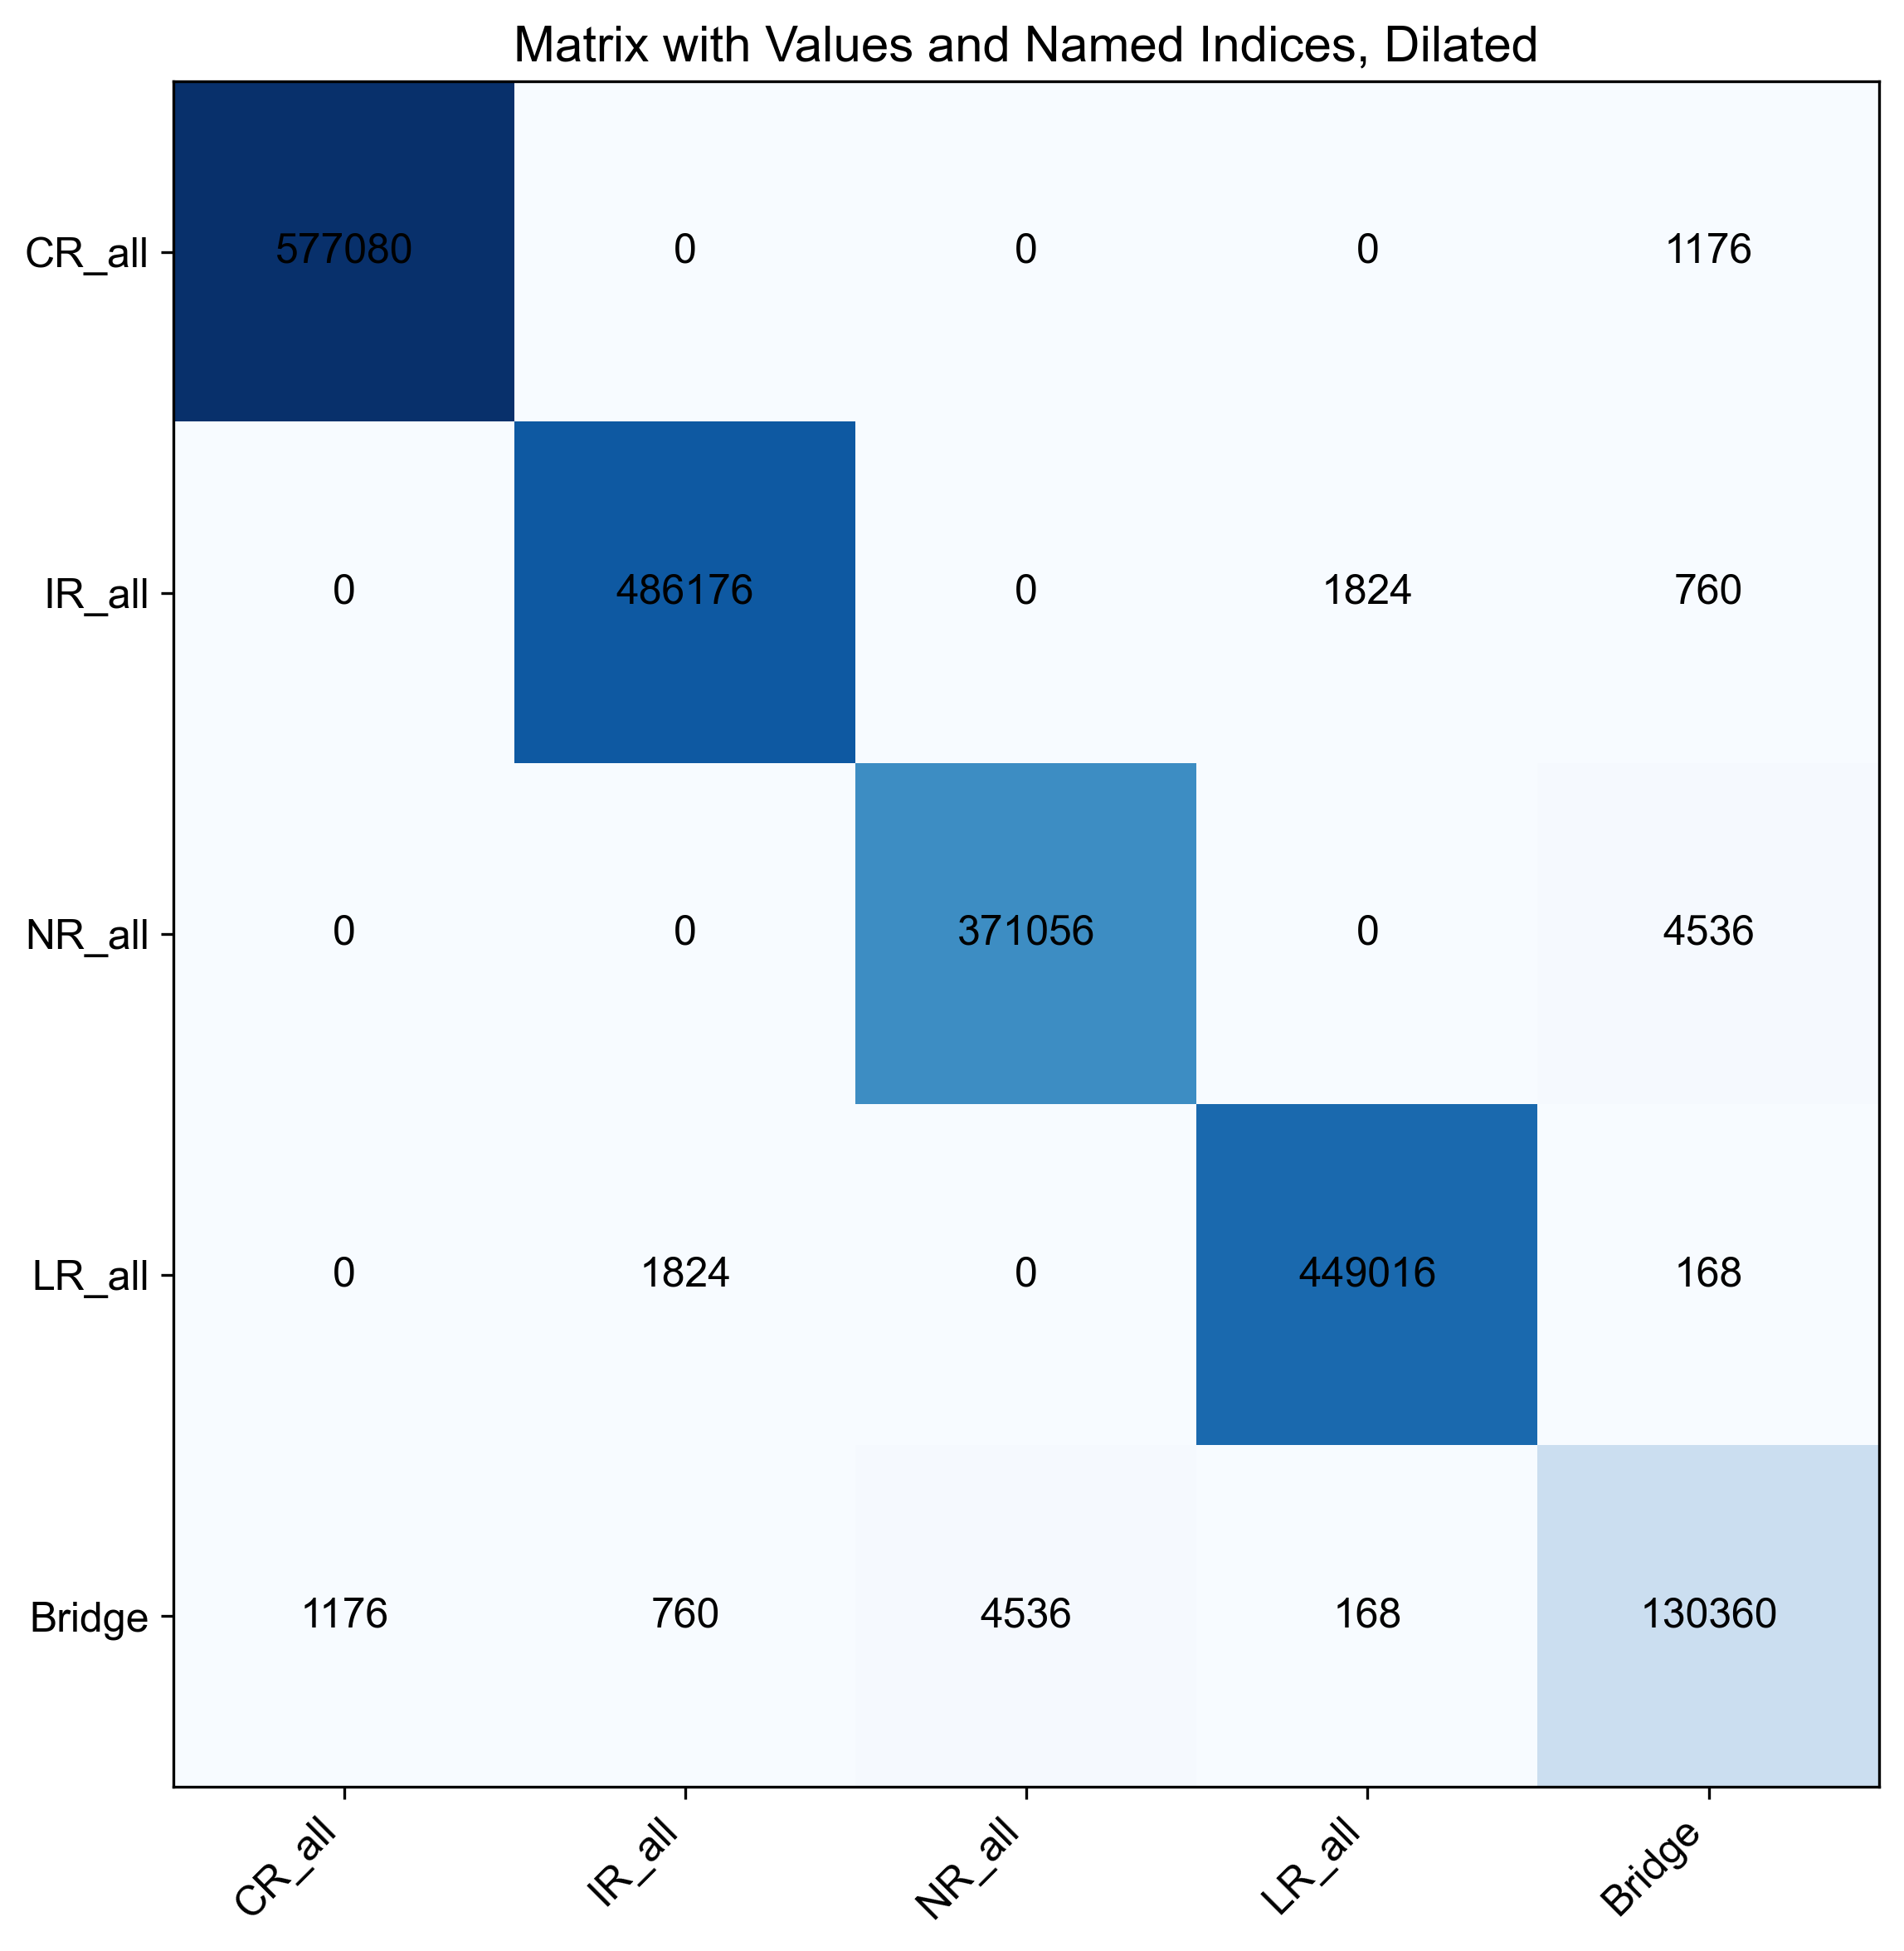

In [289]:
row_labels = list(ring_info.keys())[:5]
col_labels = list(ring_info.keys())[:5]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(contact_matrix_dilated, cmap='Blues')

# Show all values in the matrix
for i in range(contact_matrix_dilated.shape[0]):
    for j in range(contact_matrix_dilated.shape[1]):
        ax.text(j, i, str(contact_matrix_dilated[i, j]),
                ha='center', va='center', color='black')

# Set ticks and labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

# Optional: Rotate the tick labels and layout
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


plt.title("Matrix with Values and Named Indices, Dilated")
plt.tight_layout()
plt.show()


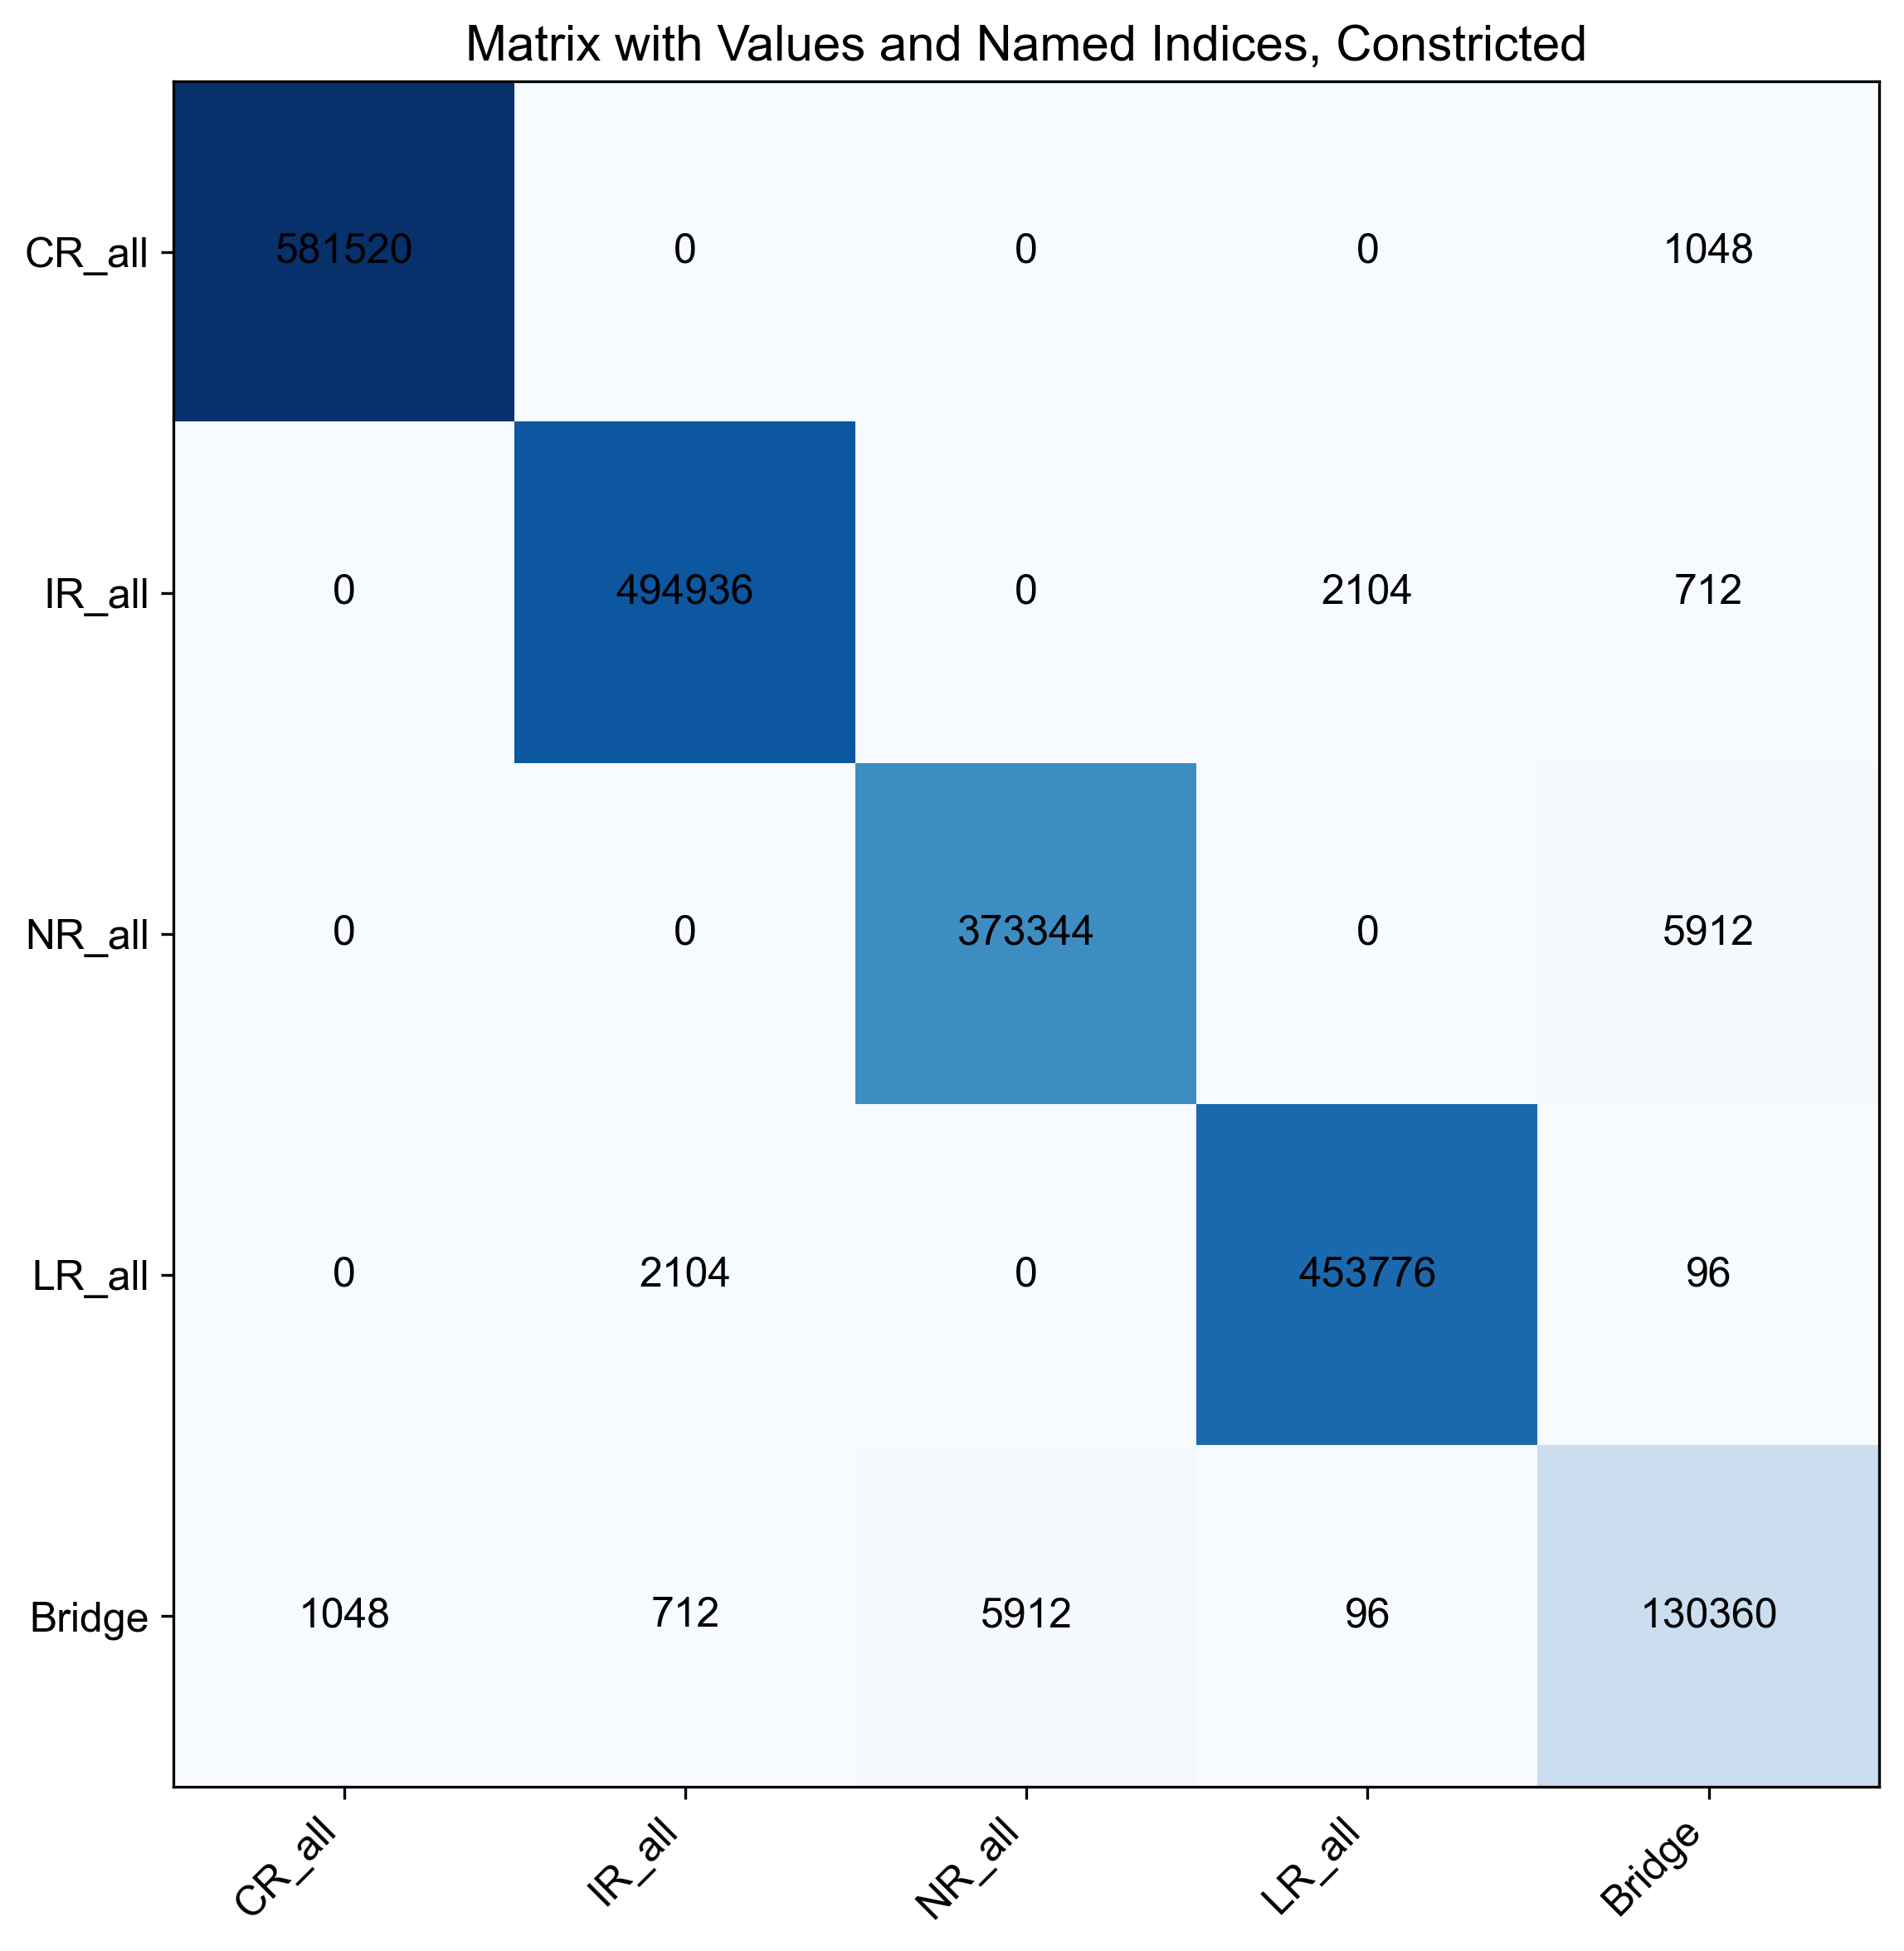

In [290]:
row_labels = list(ring_info.keys())[:5]
col_labels = list(ring_info.keys())[:5]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(contact_matrix_constricted, cmap='Blues')

# Show all values in the matrix
for i in range(contact_matrix_constricted.shape[0]):
    for j in range(contact_matrix_constricted.shape[1]):
        ax.text(j, i, str(contact_matrix_constricted[i, j]),
                ha='center', va='center', color='black')

# Set ticks and labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

# Optional: Rotate the tick labels and layout
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


plt.title("Matrix with Values and Named Indices, Constricted")
plt.tight_layout()
plt.show()
